# Olist Brazilian E-Commerce Analysis

### Python Data Analyst Portfolio Project

**Objective:** analyze order activity, product-category performance, customer geography, delivery performance, payment behavior, and repeat-customer patterns.

**Tools:** Python, pandas, NumPy, Matplotlib, KaggleHub

**Dataset:** [Olist Brazilian E-Commerce on Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

**Workflow:** Kaggle data access → data quality audit → grain validation → order-level data model → EDA → business insights

> Findings are descriptive associations. They do not establish causality.

## 1. Business Context & Questions

This end-to-end Data Analyst case study addresses:

1. What is the distribution of order statuses?
2. How did delivered-order volume and payment value change over time?
3. Which product categories generated the highest product sales value?
4. Which customer states contributed the most delivered orders and payment value?
5. How often were delivered orders late, and how did review scores differ by delivery timeliness?
6. Which payment methods accounted for the largest payment value?
7. How common were repeat customers among delivered orders?

### Scope decisions

- Order status uses all orders; commercial and delivery analyses focus on delivered orders.
- Payment records are aggregated to order level before joining to avoid double counting.
- Product-category analysis uses item price as product sales value, not accounting revenue.
- State analysis uses the customer state field directly; the geolocation table is audited but not needed for the core questions.

## 2. Google Colab Setup

Run the notebook from top to bottom in Google Colab with internet access enabled. The source tables are loaded from Kaggle with KaggleHub; this notebook does not search for local CSV files.

In [1]:
%pip -q install "kagglehub[pandas-datasets]"


In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display, Markdown

import kagglehub
from kagglehub import KaggleDatasetAdapter

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

plt.style.use("ggplot")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "font.size": 10,
})

## 3. Load the Source Tables from Kaggle

Each of the nine source CSV files is requested directly from the public Kaggle dataset handle. KaggleHub caches files in the Colab runtime and loads each selected file as a pandas DataFrame.

In [3]:
DATASET_HANDLE = "olistbr/brazilian-ecommerce"

FILE_PATHS = {
    "customers": "olist_customers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "translation": "product_category_name_translation.csv",
}

tables = {}

try:
    for table_name, file_path in FILE_PATHS.items():
        tables[table_name] = kagglehub.dataset_load(
            KaggleDatasetAdapter.PANDAS,
            DATASET_HANDLE,
            file_path,
            pandas_kwargs={"low_memory": False},
        )
except Exception as error:
    raise RuntimeError(
        "Could not load the Olist dataset from Kaggle. Check internet access "
        "and verify that the Kaggle dataset is available to this runtime."
    ) from error

print(f"Loaded {len(tables)} source tables from Kaggle: {DATASET_HANDLE}")

shape_summary = pd.DataFrame(
    [{"table": name, "rows": len(df), "columns": df.shape[1]} for name, df in tables.items()]
).sort_values("rows", ascending=False)

shape_summary

100%|██████████| 4.59M/4.59M [00:01<00:00, 3.63MB/s]

Extracting zip of olist_customers_dataset.csv...


100%|██████████| 14.9M/14.9M [00:01<00:00, 8.25MB/s]

Extracting zip of olist_geolocation_dataset.csv...


Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Loaded 9 source tables from Kaggle: olistbr/brazilian-ecommerce


,table,rows,columns
1,geolocation,1000163,5
2,order_items,112650,7
3,payments,103886,5
0,customers,99441,5
5,orders,99441,8
4,reviews,99224,7
6,products,32951,9
7,sellers,3095,4
8,translation,71,2


## 4. Data Quality Audit

Before analysis, inspect exact duplicate rows and missing values.

A high duplicate count does not automatically mean records should be deleted. Duplicate handling depends on table grain and business meaning. For example, the geolocation table can contain repeated coordinates or ZIP combinations and is not used directly in the core order-level model below.

In [4]:
quality_rows = []

for name, df in tables.items():
    missing_cells = int(df.isna().sum().sum())
    quality_rows.append({
        "table": name,
        "rows": len(df),
        "exact_duplicate_rows": int(df.duplicated().sum()),
        "missing_cells": missing_cells,
        "missing_cell_pct": missing_cells / df.size * 100,
    })

quality_summary = pd.DataFrame(quality_rows).sort_values("rows", ascending=False)
quality_summary

,table,rows,exact_duplicate_rows,missing_cells,missing_cell_pct
1,geolocation,1000163,261831,0,0.00
2,order_items,112650,0,0,0.00
3,payments,103886,0,0,0.00
0,customers,99441,0,0,0.00
5,orders,99441,0,4908,0.62
4,reviews,99224,0,145903,21.01
6,products,32951,0,2448,0.83
7,sellers,3095,0,0,0.00
8,translation,71,0,0,0.00


In [5]:
missing_by_column = []

for name, df in tables.items():
    missing = df.isna().sum()
    for column, count in missing[missing > 0].items():
        missing_by_column.append({
            "table": name,
            "column": column,
            "missing_count": int(count),
            "missing_pct": count / len(df) * 100,
        })

pd.DataFrame(missing_by_column).sort_values(
    ["table", "missing_count"], ascending=[True, False]
)

,table,column,missing_count,missing_pct
4,orders,order_delivered_customer_date,2965,2.98
3,orders,order_delivered_carrier_date,1783,1.79
2,orders,order_approved_at,160,0.16
5,products,product_category_name,610,1.85
6,products,product_name_lenght,610,1.85
7,products,product_description_lenght,610,1.85
8,products,product_photos_qty,610,1.85
9,products,product_weight_g,2,0.01
10,products,product_length_cm,2,0.01
11,products,product_height_cm,2,0.01


### Grain and key validation

This is one of the most important parts of the project.

- orders: one row per order_id
- customers: one row per customer_id
- products: one row per product_id
- sellers: one row per seller_id
- product-category translation: one row per source category
- order_items: multiple rows can belong to one order
- payments: multiple payment records can belong to one order
- reviews: some orders have more than one review record

Therefore, item, payment, and review tables must be aggregated to order level before they are merged into an order-level fact table.

In [6]:
orders = tables["orders"].copy()
customers = tables["customers"].copy()
order_items = tables["order_items"].copy()
payments = tables["payments"].copy()
reviews = tables["reviews"].copy()
products = tables["products"].copy()
sellers = tables["sellers"].copy()
translation = tables["translation"].copy()
geolocation = tables["geolocation"].copy()

key_checks = pd.DataFrame({
    "table": ["orders", "customers", "products", "sellers", "translation", "order_items"],
    "key": [
        "order_id",
        "customer_id",
        "product_id",
        "seller_id",
        "product_category_name",
        "(order_id, order_item_id)",
    ],
    "is_unique": [
        orders["order_id"].is_unique,
        customers["customer_id"].is_unique,
        products["product_id"].is_unique,
        sellers["seller_id"].is_unique,
        translation["product_category_name"].is_unique,
        not order_items.duplicated(["order_id", "order_item_id"]).any(),
    ],
})

display(key_checks)

if not key_checks["is_unique"].all():
    raise ValueError("A required source key is not unique. Review key_checks before continuing.")

,table,key,is_unique
0,orders,order_id,True
1,customers,customer_id,True
2,products,product_id,True
3,sellers,seller_id,True
4,translation,product_category_name,True
5,order_items,"(order_id, order_item_id)",True


In [7]:
relationship_checks = pd.DataFrame({
    "relationship": [
        "Orders with multiple item rows",
        "Orders with multiple payment rows",
        "Duplicate order_id rows in reviews",
    ],
    "count": [
        int((order_items.groupby("order_id").size() > 1).sum()),
        int((payments.groupby("order_id").size() > 1).sum()),
        int(reviews["order_id"].duplicated().sum()),
    ],
})

relationship_checks

,relationship,count
0,Orders with multiple item rows,9803
1,Orders with multiple payment rows,2961
2,Duplicate order_id rows in reviews,551


## 5. Data Preparation & Feature Engineering

Dates are converted to `datetime`. Product category names are translated to English when a translation is available.

The analysis creates an order-level fact table by first aggregating one-to-many tables.

In [8]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

order_items["shipping_limit_date"] = pd.to_datetime(
    order_items["shipping_limit_date"], errors="coerce"
)

for col in ["review_creation_date", "review_answer_timestamp"]:
    reviews[col] = pd.to_datetime(reviews[col], errors="coerce")

products = products.merge(
    translation,
    on="product_category_name",
    how="left",
    validate="many_to_one",
)

products["category"] = (
    products["product_category_name_english"]
    .fillna(products["product_category_name"])
    .fillna("unknown")
)

print("Date conversion and product-category translation complete.")

Date conversion and product-category translation complete.


In [9]:
# Aggregate each one-to-many table to order level before joining.
order_item_agg = (
    order_items.groupby("order_id", as_index=False)
    .agg(
        item_count=("order_item_id", "size"),
        distinct_products=("product_id", "nunique"),
        distinct_sellers=("seller_id", "nunique"),
        product_sales_value=("price", lambda values: values.sum(min_count=1)),
        freight_value=("freight_value", lambda values: values.sum(min_count=1)),
    )
)

payment_agg = (
    payments.groupby("order_id", as_index=False)
    .agg(
        payment_value=("payment_value", lambda values: values.sum(min_count=1)),
        payment_records=("payment_type", "size"),
        max_installments=("payment_installments", "max"),
    )
)

review_agg = (
    reviews.groupby("order_id", as_index=False)
    .agg(
        review_score=("review_score", "mean"),
        review_records=("review_id", "size"),
    )
)

order_fact = (
    orders
    .merge(customers, on="customer_id", how="left", validate="many_to_one")
    .merge(order_item_agg, on="order_id", how="left", validate="one_to_one")
    .merge(payment_agg, on="order_id", how="left", validate="one_to_one")
    .merge(review_agg, on="order_id", how="left", validate="one_to_one")
)

order_fact["purchase_month"] = (
    order_fact["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
)

order_fact["delivery_days"] = (
    order_fact["order_delivered_customer_date"] - order_fact["order_purchase_timestamp"]
).dt.total_seconds() / 86400

order_fact["delivery_delay_days"] = (
    order_fact["order_delivered_customer_date"] - order_fact["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

has_delivery_dates = (
    order_fact["order_delivered_customer_date"].notna()
    & order_fact["order_estimated_delivery_date"].notna()
)
order_fact["late_delivery"] = pd.Series(
    pd.NA, index=order_fact.index, dtype="boolean"
)
order_fact.loc[has_delivery_dates, "late_delivery"] = (
    order_fact.loc[has_delivery_dates, "delivery_delay_days"] > 0
)

if len(order_fact) != len(orders) or not order_fact["order_id"].is_unique:
    raise AssertionError("Order-level joins changed the order grain.")

print(f"Order-level fact table: {order_fact.shape[0]:,} rows × {order_fact.shape[1]} columns")

Order-level fact table: 99,441 rows × 26 columns


### Analysis population

The full order table is retained for status analysis. Most subsequent business analyses use **delivered orders**, because delivery duration and completed transaction metrics are only meaningful for fulfilled orders.

In [10]:
delivered = order_fact.loc[order_fact["order_status"].eq("delivered")].copy()
delivered_ids = set(delivered["order_id"])

delivery_eligible = delivered.dropna(
    subset=["delivery_days", "delivery_delay_days", "late_delivery"]
).copy()

analysis_scope = pd.DataFrame({
    "metric": [
        "All orders",
        "Delivered orders",
        "Delivered orders with complete delivery dates",
        "Delivered unique customers",
        "First observed purchase",
        "Last observed purchase",
    ],
    "value": [
        f"{order_fact['order_id'].nunique():,}",
        f"{delivered['order_id'].nunique():,}",
        f"{delivery_eligible['order_id'].nunique():,}",
        f"{delivered['customer_unique_id'].nunique():,}",
        str(order_fact["order_purchase_timestamp"].min()),
        str(order_fact["order_purchase_timestamp"].max()),
    ],
})

display(analysis_scope)

raw_payment_total = payments.loc[
    payments["order_id"].isin(delivered_ids), "payment_value"
].sum(min_count=1)
fact_payment_total = delivered["payment_value"].sum(min_count=1)

if not np.isclose(raw_payment_total, fact_payment_total, rtol=1e-10, atol=1e-6, equal_nan=True):
    raise AssertionError("Payment total changed after order-level aggregation.")

print(f"Payment reconciliation difference: {raw_payment_total - fact_payment_total:,.6f}")

,metric,value
0,All orders,"99,441"
1,Delivered orders,"96,478"
2,Delivered orders with complete delivery dates,"96,470"
3,Delivered unique customers,"93,358"
4,First observed purchase,2016-09-04 21:15:19
5,Last observed purchase,2018-10-17 17:30:18


Payment reconciliation difference: 0.000000


## 6. Analysis 1 — Order Status

Order status provides context before focusing on fulfilled transactions.

In [11]:
status_summary = (
    order_fact["order_status"]
    .value_counts()
    .rename_axis("order_status")
    .reset_index(name="orders")
)

status_summary["share_pct"] = status_summary["orders"] / status_summary["orders"].sum() * 100
status_summary

,order_status,orders,share_pct
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


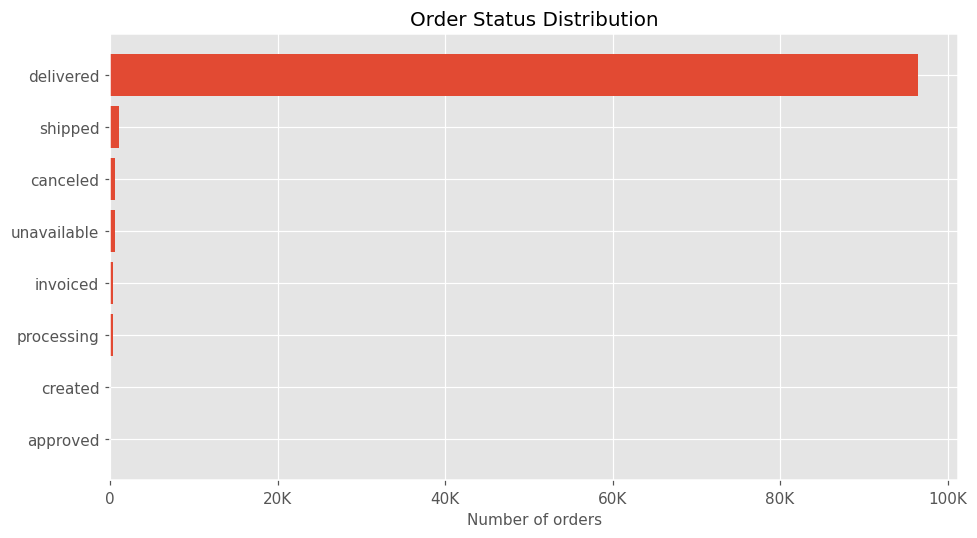

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_data = status_summary.sort_values("orders")
ax.barh(plot_data["order_status"], plot_data["orders"])
ax.set_title("Order Status Distribution")
ax.set_xlabel("Number of orders")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1000:.0f}K" if x >= 1000 else f"{x:.0f}"))
plt.tight_layout()
plt.show()

## 7. Analysis 2 — Monthly Delivered Orders & Payment Value

Two separate metrics are examined:

- **Delivered orders:** number of unique delivered `order_id`
- **Payment value:** sum of order-level `payment_value` for delivered orders

The first and last years are only partially covered, so year-to-year totals should not be compared without accounting for incomplete periods.

In [13]:
monthly = (
    delivered.groupby("purchase_month", as_index=False)
    .agg(
        delivered_orders=("order_id", "nunique"),
        payment_value=("payment_value", lambda values: values.sum(min_count=1)),
    )
)

monthly

,purchase_month,delivered_orders,payment_value
0,2016-09-01,1,NaN
1,2016-10-01,265,"46,566.71"
2,2016-12-01,1,19.62
3,2017-01-01,750,"127,545.67"
4,2017-02-01,1653,"271,298.65"
5,2017-03-01,2546,"414,369.39"
6,2017-04-01,2303,"390,952.18"
7,2017-05-01,3546,"567,066.73"
8,2017-06-01,3135,"490,225.60"
9,2017-07-01,3872,"566,403.93"


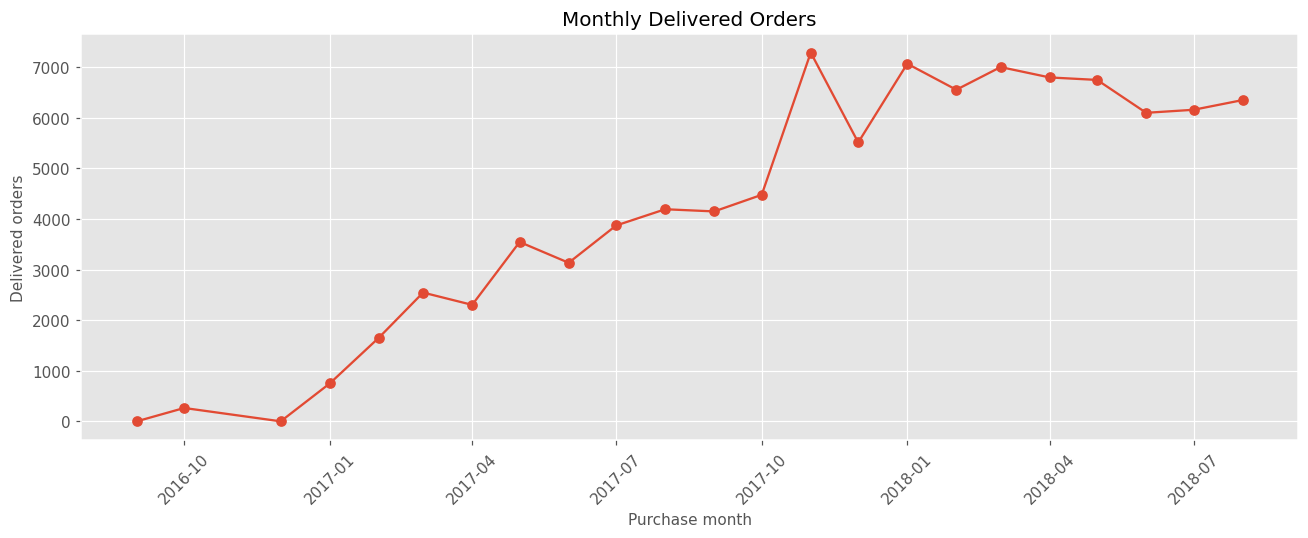

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly["purchase_month"], monthly["delivered_orders"], marker="o")
ax.set_title("Monthly Delivered Orders")
ax.set_xlabel("Purchase month")
ax.set_ylabel("Delivered orders")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

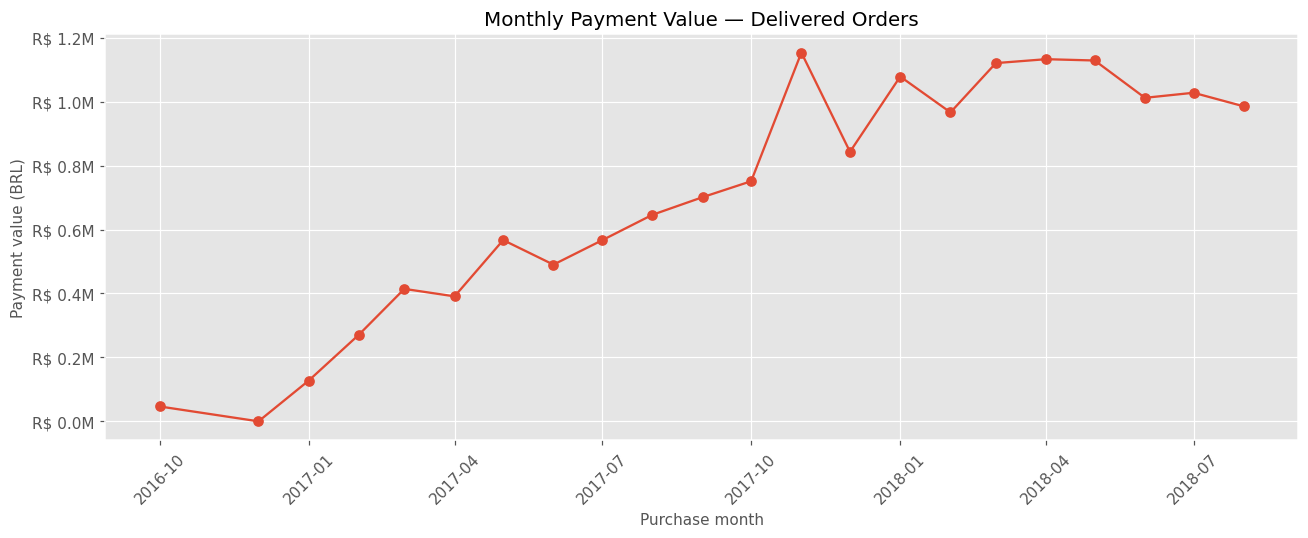

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly["purchase_month"], monthly["payment_value"], marker="o")
ax.set_title("Monthly Payment Value — Delivered Orders")
ax.set_xlabel("Purchase month")
ax.set_ylabel("Payment value (BRL)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"R$ {x/1_000_000:.1f}M"))
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [16]:
peak_orders = monthly.loc[monthly["delivered_orders"].idxmax()]
peak_payment = monthly.loc[monthly["payment_value"].idxmax()]

pd.DataFrame({
    "metric": ["Peak observed month by delivered orders", "Peak observed month by payment value"],
    "month": [
        peak_orders["purchase_month"].strftime("%Y-%m"),
        peak_payment["purchase_month"].strftime("%Y-%m"),
    ],
    "value": [
        f"{int(peak_orders['delivered_orders']):,} orders",
        f"{peak_payment['payment_value']:,.2f}",
    ],
})

,metric,month,value
0,Peak observed month by delivered orders,2017-11,"7,289 orders"
1,Peak observed month by payment value,2017-11,"1,153,528.05"


## 8. Analysis 3 — Product Category Performance

For category analysis, delivered order items are joined to the translated product categories.

`product_sales_value` is the sum of item `price`. It is intentionally not labeled accounting revenue because the dataset does not provide a complete financial statement context.

In [17]:
delivered_ids = set(delivered["order_id"])

delivered_items = (
    order_items.loc[order_items["order_id"].isin(delivered_ids)]
    .merge(
        products[["product_id", "category"]],
        on="product_id",
        how="left",
        validate="many_to_one"
    )
)

expected_item_rows = int(order_items["order_id"].isin(delivered_ids).sum())
if len(delivered_items) != expected_item_rows:
    raise AssertionError("Product-category join changed the delivered item row count.")

category_performance = (
    delivered_items.groupby("category", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        items=("order_item_id", "count"),
        product_sales_value=("price", "sum"),
    )
    .sort_values("product_sales_value", ascending=False)
)

category_performance.head(10)

,category,orders,items,product_sales_value
43,health_beauty,8647,9465,"1,233,131.72"
73,watches_gifts,5495,5859,"1,166,176.98"
7,bed_bath_table,9272,10953,"1,023,434.76"
67,sports_leisure,7530,8431,"954,852.55"
15,computers_accessories,6530,7644,"888,724.61"
39,furniture_decor,6307,8160,"711,927.69"
49,housewares,5743,6795,"615,628.69"
20,cool_stuff,3559,3718,"610,204.10"
5,auto,3810,4140,"578,966.65"
71,toys,3804,4030,"471,286.48"


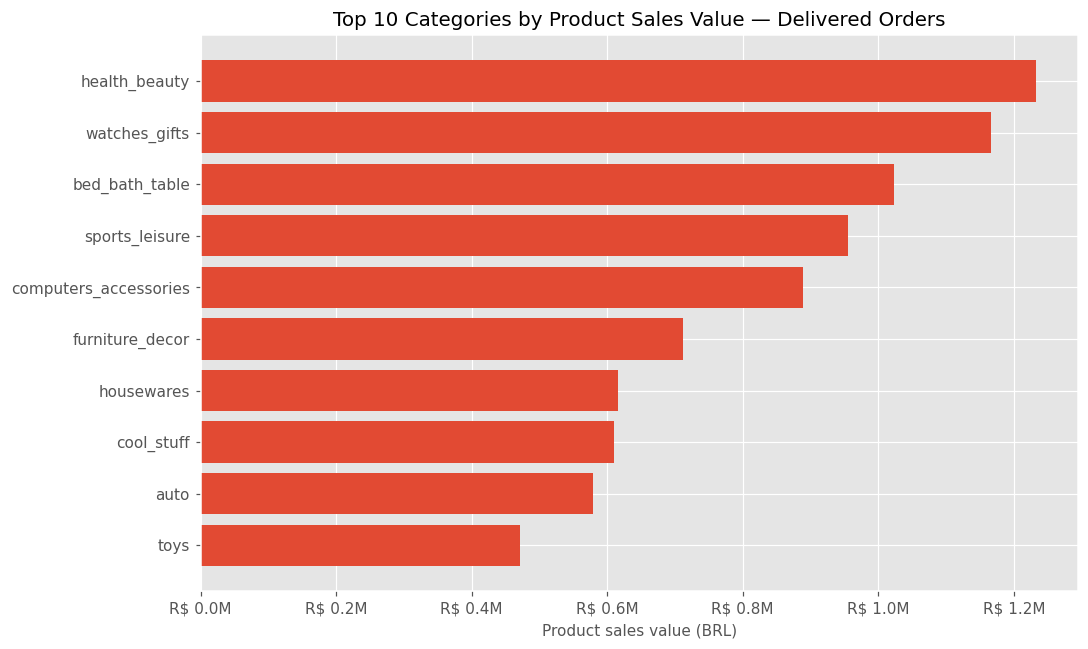

In [18]:
top_categories = category_performance.head(10).sort_values("product_sales_value")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_categories["category"], top_categories["product_sales_value"])
ax.set_title("Top 10 Categories by Product Sales Value — Delivered Orders")
ax.set_xlabel("Product sales value (BRL)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"R$ {x/1_000_000:.1f}M"))
plt.tight_layout()
plt.show()

## 9. Analysis 4 — Customer Geography

Customer state is taken directly from the customers table. This avoids unnecessary dependence on the much larger geolocation table for a question that can already be answered at state level.

In [19]:
state_performance = (
    delivered.groupby("customer_state", as_index=False)
    .agg(
        delivered_orders=("order_id", "nunique"),
        payment_value=("payment_value", "sum"),
        avg_order_payment=("payment_value", "mean"),
    )
    .sort_values("payment_value", ascending=False)
)

state_performance.head(10)

,customer_state,delivered_orders,payment_value,avg_order_payment
25,SP,40501,"5,770,266.19",142.48
18,RJ,12350,"2,055,690.45",166.45
10,MG,11354,"1,819,277.61",160.23
22,RS,5345,"861,802.40",161.24
17,PR,4923,"781,919.55",158.83
23,SC,3546,"595,208.40",167.85
4,BA,3256,"591,270.60",181.59
6,DF,2080,"346,146.17",166.42
8,GO,1957,"334,294.22",170.82
7,ES,1995,"317,682.65",159.24


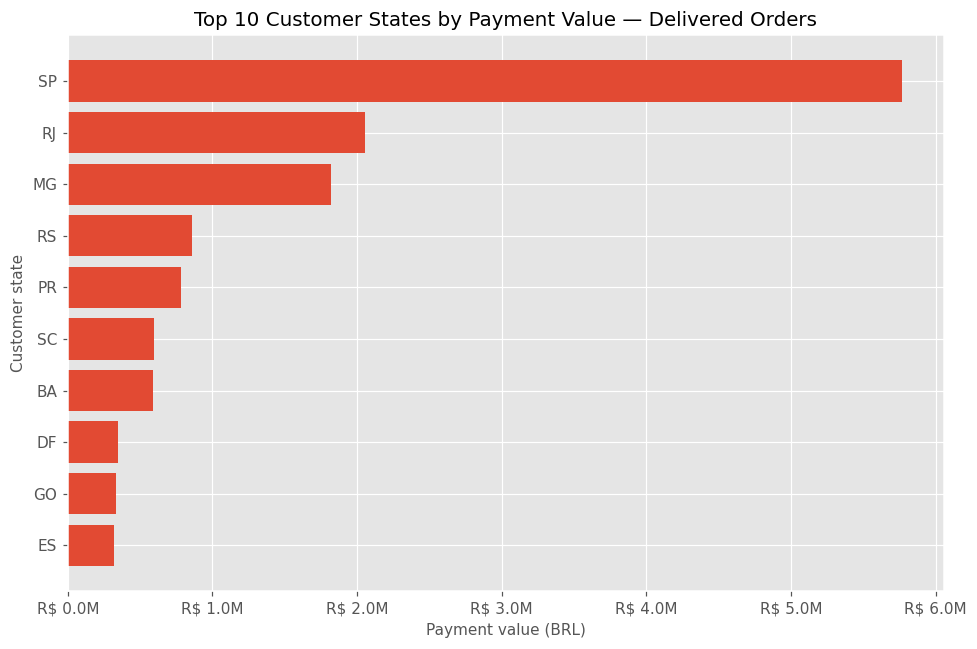

In [20]:
top_states = state_performance.head(10).sort_values("payment_value")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_states["customer_state"], top_states["payment_value"])
ax.set_title("Top 10 Customer States by Payment Value — Delivered Orders")
ax.set_xlabel("Payment value (BRL)")
ax.set_ylabel("Customer state")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"R$ {x/1_000_000:.1f}M"))
plt.tight_layout()
plt.show()

## 10. Analysis 5 — Delivery Performance & Reviews

An order is classified as **late** when the actual customer delivery timestamp is later than the estimated delivery date.

The comparison below is descriptive. A lower review score among late deliveries does not, by itself, prove that delivery delay caused the review score.

In [21]:
delivery_metrics = pd.DataFrame({
    "metric": [
        "Delivered orders",
        "Orders with complete delivery dates",
        "Median delivery time (days)",
        "Average delivery time (days)",
        "Late deliveries",
        "Late delivery rate among date-complete delivered orders",
        "Average review score for delivered orders with a review",
    ],
    "value": [
        f"{delivered['order_id'].nunique():,}",
        f"{delivery_eligible['order_id'].nunique():,}",
        f"{delivery_eligible['delivery_days'].median():.1f}",
        f"{delivery_eligible['delivery_days'].mean():.1f}",
        f"{int(delivery_eligible['late_delivery'].sum()):,}",
        f"{delivery_eligible['late_delivery'].mean():.1%}",
        f"{delivered['review_score'].mean():.2f}",
    ],
})

delivery_metrics

,metric,value
0,Delivered orders,"96,478"
1,Orders with complete delivery dates,"96,470"
2,Median delivery time (days),10.2
3,Average delivery time (days),12.6
4,Late deliveries,"7,826"
5,Late delivery rate among date-complete deliver...,8.1%
6,Average review score for delivered orders with...,4.16


In [22]:
review_by_delivery = (
    delivery_eligible.dropna(subset=["review_score"])
    .groupby("late_delivery", as_index=False)
    .agg(
        avg_review_score=("review_score", "mean"),
        orders=("order_id", "nunique"),
    )
)

review_by_delivery["delivery_group"] = review_by_delivery["late_delivery"].map({
    False: "Not late",
    True: "Late"
})

review_by_delivery[["delivery_group", "orders", "avg_review_score"]]

,delivery_group,orders,avg_review_score
0,Not late,88163,4.29
1,Late,7661,2.57


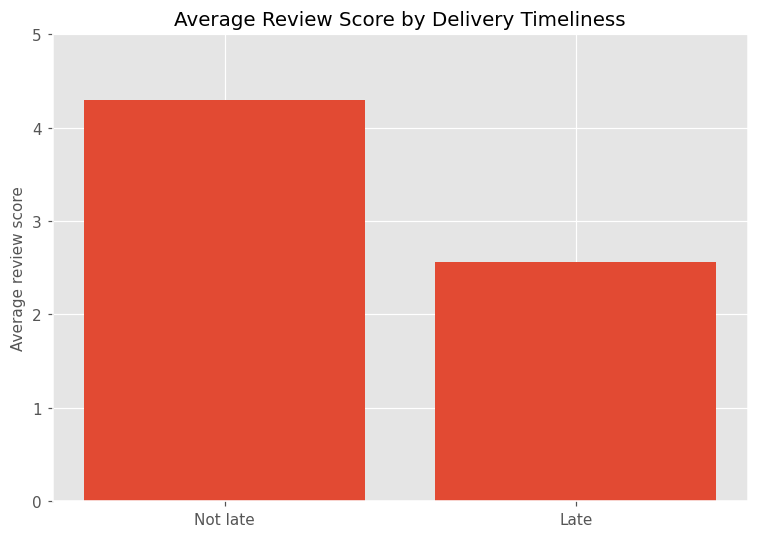

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(review_by_delivery["delivery_group"], review_by_delivery["avg_review_score"])
ax.set_title("Average Review Score by Delivery Timeliness")
ax.set_xlabel("")
ax.set_ylabel("Average review score")
ax.set_ylim(0, 5)
plt.tight_layout()
plt.show()

## 11. Analysis 6 — Payment Behavior

Payment rows are analyzed by payment type. Because one order can have multiple payment rows, both **payment records** and **unique orders** are shown.

In [24]:
delivered_payments = payments.loc[payments["order_id"].isin(delivered_ids)].copy()

payment_summary = (
    delivered_payments.groupby("payment_type", as_index=False)
    .agg(
        payment_records=("payment_sequential", "count"),
        orders=("order_id", "nunique"),
        payment_value=("payment_value", "sum"),
    )
    .sort_values("payment_value", ascending=False)
)

payment_summary["payment_value_share_pct"] = (
    payment_summary["payment_value"] / payment_summary["payment_value"].sum() * 100
)

payment_summary

,payment_type,payment_records,orders,payment_value,payment_value_share_pct
1,credit_card,74586,74304,"12,101,094.88",78.46
0,boleto,19191,19191,"2,769,932.58",17.96
3,voucher,5493,3679,"343,013.19",2.22
2,debit_card,1486,1485,"208,421.12",1.35


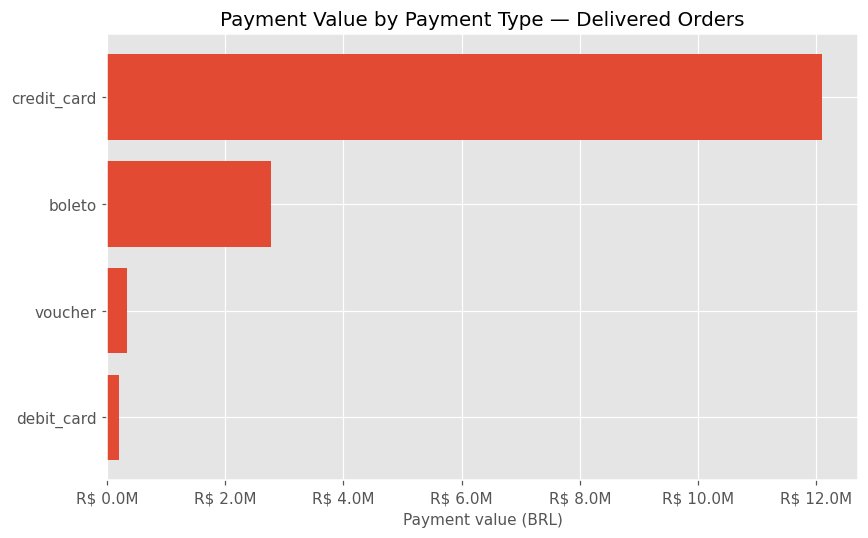

In [25]:
plot_payment = payment_summary.sort_values("payment_value")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(plot_payment["payment_type"], plot_payment["payment_value"])
ax.set_title("Payment Value by Payment Type — Delivered Orders")
ax.set_xlabel("Payment value (BRL)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"R$ {x/1_000_000:.1f}M"))
plt.tight_layout()
plt.show()

## 12. Analysis 7 — Repeat Customer Pattern

`customer_unique_id` is used to identify customers who appear across more than one delivered order.

This section measures observed repeat behavior in this dataset only. It should not be interpreted as lifetime customer retention.

In [26]:
customer_order_counts = (
    delivered.groupby("customer_unique_id")["order_id"]
    .nunique()
    .rename("delivered_orders")
)

repeat_summary = pd.DataFrame({
    "metric": [
        "Unique delivered customers",
        "Customers with >1 delivered order",
        "Observed repeat-customer rate",
        "Share of delivered orders from repeat customers",
    ],
    "value": [
        f"{customer_order_counts.size:,}",
        f"{int((customer_order_counts > 1).sum()):,}",
        f"{(customer_order_counts > 1).mean():.1%}",
        f"{customer_order_counts[customer_order_counts > 1].sum() / customer_order_counts.sum():.1%}",
    ],
})

repeat_summary

,metric,value
0,Unique delivered customers,"93,358"
1,Customers with >1 delivered order,"2,801"
2,Observed repeat-customer rate,3.0%
3,Share of delivered orders from repeat customers,6.1%


In [27]:
customer_frequency = (
    customer_order_counts.value_counts()
    .sort_index()
    .rename_axis("delivered_orders_per_customer")
    .reset_index(name="customers")
)

customer_frequency.head(10)

,delivered_orders_per_customer,customers
0,1,90557
1,2,2573
2,3,181
3,4,28
4,5,9
5,6,5
6,7,3
7,9,1
8,15,1


## 13. Portfolio KPI Summary

In [28]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Delivered orders",
        "Total payment value",
        "Average order payment",
        "Median delivery time",
        "Late delivery rate",
        "Average review score",
        "Observed repeat-customer rate",
    ],
    "Value": [
        f"{delivered['order_id'].nunique():,}",
        f"{delivered['payment_value'].sum():,.2f}",
        f"{delivered['payment_value'].mean():,.2f}",
        f"{delivered['delivery_days'].median():.1f} days",
        f"{delivered['late_delivery'].mean():.1%}",
        f"{delivered['review_score'].mean():.2f} / 5",
        f"{(customer_order_counts > 1).mean():.1%}",
    ],
})

kpi_summary

,KPI,Value
0,Delivered orders,"96,478"
1,Total payment value,"15,422,461.77"
2,Average order payment,159.86
3,Median delivery time,10.2 days
4,Late delivery rate,8.1%
5,Average review score,4.16 / 5
6,Observed repeat-customer rate,3.0%


## 14. Key Findings

Findings below are generated from the data loaded above. They update when the Kaggle dataset changes.

In [29]:
findings = []

if not status_summary.empty:
    top_status = status_summary.iloc[0]
    findings.append(
        f"Most common order status: **{top_status['order_status']}** "
        f"({int(top_status['orders']):,} orders; {top_status['share_pct']:.1f}% of all orders)."
    )

if not monthly.empty:
    peak_orders = monthly.loc[monthly["delivered_orders"].idxmax()]
    findings.append(
        f"Peak observed month by delivered-order volume: "
        f"**{peak_orders['purchase_month']:%B %Y}** "
        f"({int(peak_orders['delivered_orders']):,} delivered orders)."
    )

if not category_performance.empty:
    top_category = category_performance.iloc[0]
    findings.append(
        f"Highest product sales value among delivered-order categories: "
        f"**{top_category['category']}** (R$ {top_category['product_sales_value']:,.2f} in item prices)."
    )

if not state_performance.empty:
    top_state = state_performance.iloc[0]
    findings.append(
        f"Largest customer-state payment value: **{top_state['customer_state']}** "
        f"(R$ {top_state['payment_value']:,.2f} across delivered orders)."
    )

if not delivery_eligible.empty:
    findings.append(
        f"Late delivery rate among date-complete delivered orders: "
        f"**{delivery_eligible['late_delivery'].mean():.1%}** "
        f"({int(delivery_eligible['late_delivery'].sum()):,} of {len(delivery_eligible):,} orders)."
    )

if not review_by_delivery.empty:
    review_lookup = review_by_delivery.set_index("delivery_group")["avg_review_score"]
    if "Late" in review_lookup.index and "Not late" in review_lookup.index:
        score_gap = review_lookup["Not late"] - review_lookup["Late"]
        findings.append(
            f"Average review score was {score_gap:.2f} points higher for date-complete, "
            "non-late orders than for late orders. This is a descriptive association, not a causal estimate."
        )

if not payment_summary.empty:
    top_payment = payment_summary.iloc[0]
    findings.append(
        f"Largest payment value by payment type: **{top_payment['payment_type']}** "
        f"({top_payment['payment_value_share_pct']:.1f}% of delivered-order payment value)."
    )

if len(customer_order_counts):
    findings.append(
        f"Observed repeat-customer rate among delivered customers with an ID: "
        f"**{(customer_order_counts > 1).mean():.1%}** within the dataset window."
    )

display(Markdown("\n".join(f"{index}. {finding}" for index, finding in enumerate(findings, start=1))))

1. Most common order status: **delivered** (96,478 orders; 97.0% of all orders).
2. Peak observed month by delivered-order volume: **November 2017** (7,289 delivered orders).
3. Highest product sales value among delivered-order categories: **health_beauty** (R$ 1,233,131.72 in item prices).
4. Largest customer-state payment value: **SP** (R$ 5,770,266.19 across delivered orders).
5. Late delivery rate among date-complete delivered orders: **8.1%** (7,826 of 96,470 orders).
6. Average review score was 1.73 points higher for date-complete, non-late orders than for late orders. This is a descriptive association, not a causal estimate.
7. Largest payment value by payment type: **credit_card** (78.5% of delivered-order payment value).
8. Observed repeat-customer rate among delivered customers with an ID: **3.0%** within the dataset window.

## 15. Business Recommendations

These recommendations are based on the current results and are prompts for further investigation. They do not assume a single cause for any observed pattern.

In [30]:
recommendations = []

if not delivery_eligible.empty:
    late_count = int(delivery_eligible["late_delivery"].sum())
    recommendations.append(
        f"Review delivery operations for the {late_count:,} date-complete delivered orders "
        "classified as late. Compare results by seller, route, and month before selecting an intervention."
    )

if not category_performance.empty:
    top_category_name = category_performance.iloc[0]["category"]
    recommendations.append(
        f"Assess inventory and seller coverage for {top_category_name}, the leading category by "
        "delivered-item price value, together with stockout, cost, and margin data."
    )

if not state_performance.empty:
    top_state_name = state_performance.iloc[0]["customer_state"]
    recommendations.append(
        f"Use {top_state_name} as a starting point for a state-level service and demand review, "
        "then compare with delivery cost and market size."
    )

if not payment_summary.empty:
    top_payment_type = payment_summary.iloc[0]["payment_type"]
    recommendations.append(
        f"Review checkout and payment operations for {top_payment_type}, which has the largest "
        "delivered-order payment value; also consider fees, refunds, and payment success."
    )

if len(customer_order_counts):
    recommendations.append(
        f"Track repeat purchasing by customer cohort over time; the observed within-window repeat "
        f"rate is {(customer_order_counts > 1).mean():.1%} among delivered customers with an ID."
    )

display(Markdown("\n".join(f"- {item}" for item in recommendations)))

- Review delivery operations for the 7,826 date-complete delivered orders classified as late. Compare results by seller, route, and month before selecting an intervention.
- Assess inventory and seller coverage for health_beauty, the leading category by delivered-item price value, together with stockout, cost, and margin data.
- Use SP as a starting point for a state-level service and demand review, then compare with delivery cost and market size.
- Review checkout and payment operations for credit_card, which has the largest delivered-order payment value; also consider fees, refunds, and payment success.
- Track repeat purchasing by customer cohort over time; the observed within-window repeat rate is 3.0% among delivered customers with an ID.

## 16. Limitations

- The dataset is observational; associations should not be interpreted as causal effects.
- The observation window is not composed exclusively of complete calendar years.
- `payment_value` is a transaction/payment measure and is not treated as accounting profit or net revenue.
- Product-category value uses item `price`; freight, refunds, fees, and profitability are not allocated to categories here.
- Some orders contain multiple review or payment records, which is why those tables were aggregated before order-level joins.
- Review text is not analyzed in this notebook.
- Geolocation is not used in the core analysis because state-level geography is available directly from customer records.
- Observed repeat-customer rate is limited to the available dataset period and should not be interpreted as lifetime retention.